DIABETES PREDICTION WITH ML

In [1]:
!pip install xgboost joblib shap -q

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df = pd.read_csv("diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Analysis

In [4]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [7]:
(df[cols] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


Feature Engineering

In [8]:
df["BMI_Age"] = df["BMI"] * df["Age"]

df["Glucose_BMI"] = df["Glucose"] * df["BMI"]

df["Health_Index"] = (
    0.4 * df["Glucose"]
    + 0.3 * df["BMI"]
    + 0.3 * df["Age"]
)

In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI,Health_Index
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,4972.8,84.28
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,2261.0,51.28
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,4263.9,89.79
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,2500.9,50.33
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,5904.7,77.63


In [10]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Training XGBoost Model

In [26]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:,1]

Model Evaluation

In [27]:
accuracy = accuracy_score(y_test, predictions)

roc = roc_auc_score(
    y_test,
    probabilities
)

print("Accuracy:", round(accuracy*100,2), "%")

print("ROC AUC:", round(roc,3))

Accuracy: 75.97 %
ROC AUC: 0.829


In [28]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



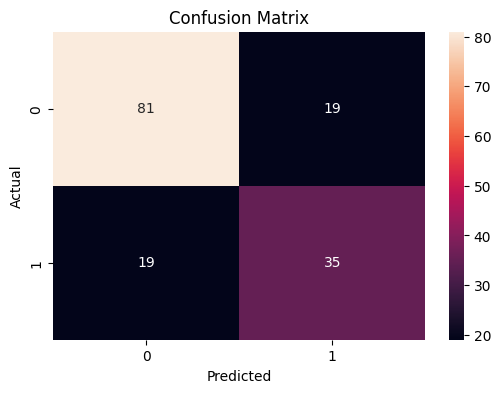

In [16]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

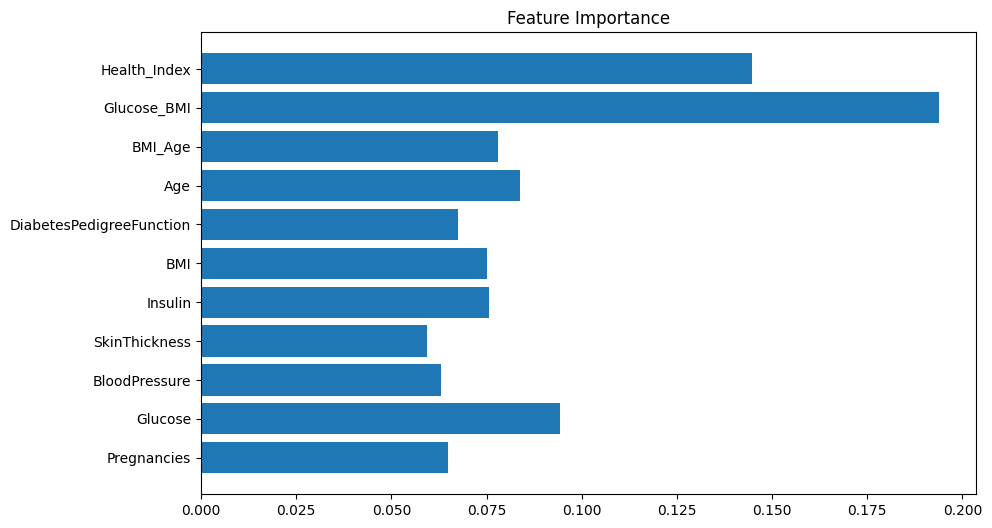

In [17]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

In [18]:
joblib.dump(
    model,
    "model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from flask import Flask, render_template, request
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("model.pkl")


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/predict", methods=["POST"])
def predict():

    pregnancies = float(request.form["Pregnancies"])
    glucose = float(request.form["Glucose"])
    blood_pressure = float(request.form["BloodPressure"])
    skin_thickness = float(request.form["SkinThickness"])
    insulin = float(request.form["Insulin"])
    bmi = float(request.form["BMI"])
    dpf = float(request.form["DiabetesPedigreeFunction"])
    age = float(request.form["Age"])

    bmi_age = bmi * age

    glucose_bmi = glucose * bmi

    health_index = (
        0.4 * glucose +
        0.3 * bmi +
        0.3 * age
    )

    features = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        dpf,
        age,
        bmi_age,
        glucose_bmi,
        health_index
    ]])

    prediction = model.predict(features)[0]

    probability = round(
        model.predict_proba(features)[0][1] * 100,
        2
    )

    if prediction == 1:
        result = "High Diabetes Risk"
    else:
        result = "Low Diabetes Risk"

    return render_template(
        "index.html",
        prediction=result,
        probability=probability
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
